# 🔬 Deep Learning aplicado à Nanotecnologia: Classificação de Micrografias MEV via TensorFlow

### Autor: Gabriel Sales Ribeiro
### Data: 14/01/2026

---

## 📝 Objetivo do Projeto
Este notebook demonstra o desenvolvimento de um pipeline de **Visão Computacional** para automatizar a identificação e classificação de fases estruturais em materiais à base de carbono. O foco principal é distinguir entre três classes distintas, comuns na síntese de materiais bidimensionais:

1.  **Grafite:** Material precursor, não esfoliado.
2.  **Óxido de Grafeno (GO):** Material intermediário, altamente oxidado e esfoliado.
3.  **Óxido de Grafeno Reduzido (rGO):** Material final, com recuperação parcial da rede conjugada $\pi$.

A identificação manual de MEV é um processo moroso e sujeito à subjetividade do operador. O objetivo deste modelo é fornecer uma triagem automática e padronizada para pesquisadores e indústrias de nanotecnologia.

## 🧠 Por que esta abordagem? (Metodologia Científica)
Em cenários laboratoriais e de P&D, datasets de imagens costumam ser restritos e preciosos. Treinar uma rede neural convolucional (CNN) do zero com poucas amostras invariavelmente leva ao *overfitting*. Para contornar essa limitação e viabilizar o projeto, utilizamos duas técnicas avançadas de Deep Learning:

* **Transfer Learning:** Aproveitamos o modelo **MobileNetV2** pré-treinado pelo Google no ImageNet (1.4 milhão de imagens). O modelo já "sabe" detectar bordas, texturas e formas genéricas. Nós apenas "afinou" as camadas finais para as texturas específicas dos nanomateriais.
* **Data Augmentation:** Geramos dinamicamente novas imagens de treino através de transformações aleatórias (rotação, zoom, inversão), aumentando a robustez do modelo e sua capacidade de generalização.

---

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


Found 63 images belonging to 3 classes.
Found 31 images belonging to 3 classes.

Classes detectadas: {'grafite': 0, 'oxido_grafeno': 1, 'rGO': 2}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Iniciando o treinamento (Fine-Tuning da camada final)...
Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.2857 - loss: 1.6094 - val_accuracy: 0.2903 - val_loss: 1.4327
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 193ms/step - accuracy: 0.3175 - loss: 1.4709 - val_accuracy: 0.2581 - val_loss: 1.4094
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 265ms/step - accuracy: 0.4127 - loss: 1.2557 - val_accuracy: 0.2581 - val_loss: 1.4124
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 160ms/step - accuracy: 0.2540 - loss: 1.4343 - val_accuracy: 0.2581 - val_loss: 1.3997
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 160ms/step - accuracy: 0.4127 - loss: 1.3968 - val_accuracy: 0.2258 - val_loss: 1.3801
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 161ms/step - accuracy: 0.3651 - loss: 1.2166 - val_accuracy: 0.2258 - val_loss: 1.3662
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 201ms/step - accuracy: 0.3492 - loss: 1.1916 - val_accuracy: 0.2258 - val_loss: 1.3574
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 263ms/s

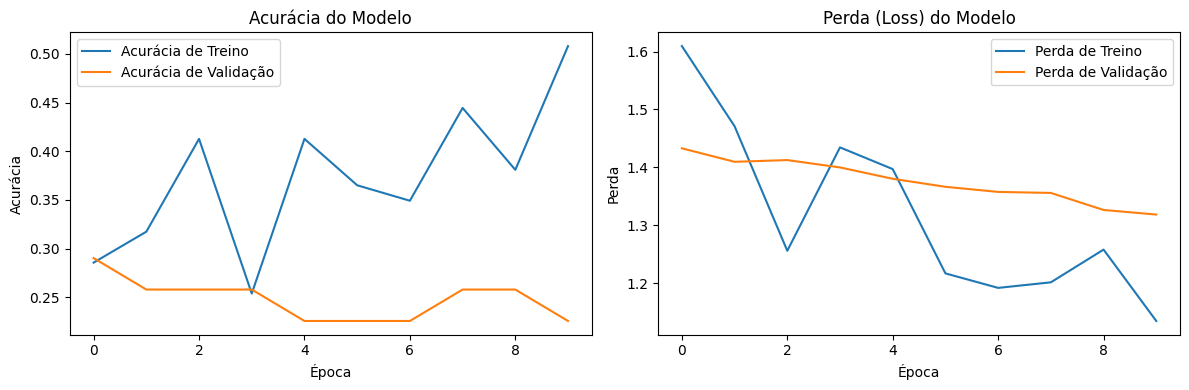


Treinamento concluído. O gráfico foi salvo como 'resultado_treinamento_mev.png'.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- 1. CONFIGURAÇÕES E PARÂMETROS ---
# Dimensões que a rede neural espera (MobileNet usa 160x160)
IMG_SIZE = (160, 160)
BATCH_SIZE = 4 # Como temos poucos dados, o batch deve ser pequeno
EPOCHS = 10    # Número de vezes que o modelo verá todo o dataset

# Defina o caminho para a sua pasta de dados (dataset_mev/)
# PATH = 'caminho/para/sua/pasta/dataset_mev'
# Para este exemplo, vamos supor que a pasta está no mesmo diretório
PATH = '/content/drive/MyDrive/Projetos pro github/dataset_mev'

# --- 2. DATA AUGMENTATION & CARREGAMENTO (A Mágica para Poucos Dados) ---

# O ImageDataGenerator cria novas imagens a partir das originais
# Ele gira, inverte horizontalmente e dá zoom aleatoriamente
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normaliza os pixels de 0-255 para 0-1 (essencial para redes neurais)
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Para validação, apenas normalizamos (não inventamos dados novos)
validation_datagen = ImageDataGenerator(rescale=1./255)

# Verificação se a pasta existe antes de tentar carregar
if not os.path.exists(PATH):
    print(f"🚨 ERRO: A pasta '{PATH}' não foi encontrada.")
    print("Por favor, crie a estrutura de pastas descrita no Passo 2 e coloque as imagens.")
    print("O código abaixo vai falhar se você continuar sem os dados.")
else:
    # Carregando os dados de treino
    train_generator = train_datagen.flow_from_directory(
        os.path.join(PATH, 'train'),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='sparse' # Usamos sparse porque temos 3 classes (0, 1, 2)
    )

    # Carregando os dados de validação
    validation_generator = validation_datagen.flow_from_directory(
        os.path.join(PATH, 'validation'),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='sparse'
    )

    print(f"\nClasses detectadas: {train_generator.class_indices}")

    # --- 3. CONSTRUINDO O MODELO (Transfer Learning) ---

    # Carregamos o MobileNetV2 pré-treinado (sem a camada final de classificação)
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(160, 160, 3),
        include_top=False,
        weights='imagenet'
    )

    # "Congelamos" a base: não queremos treinar o que o Google já treinou
    base_model.trainable = False

    # Criamos a nossa "cabeça" de classificação para os nanomateriais
    model = tf.keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(), # Transforma o mapa de características em um vetor
        layers.Dropout(0.2),             # Evita overfitting (que o modelo decore os dados)
        layers.Dense(3, activation='softmax') # Camada final com 3 neurônios (Grafite, GO, rGO)
    ])

    # --- 4. COMPILAÇÃO E TREINAMENTO ---
    base_learning_rate = 0.0001
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    model.summary()

    # Iniciando o treinamento
    print("\nIniciando o treinamento (Fine-Tuning da camada final)...")
    history = model.fit(
        train_generator,
        epochs=EPOCHS,
        validation_data=validation_generator
    )

    # --- 5. VISUALIZAÇÃO DOS RESULTADOS ---
    # Gráfico de Acurácia
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Acurácia de Treino')
    plt.plot(history.history['val_accuracy'], label='Acurácia de Validação')
    plt.title('Acurácia do Modelo')
    plt.xlabel('Época')
    plt.ylabel('Acurácia')
    plt.legend()

    # Gráfico de Perda (Loss)
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Perda de Treino')
    plt.plot(history.history['val_loss'], label='Perda de Validação')
    plt.title('Perda (Loss) do Modelo')
    plt.xlabel('Época')
    plt.ylabel('Perda')
    plt.legend()

    plt.tight_layout()
    plt.savefig('resultado_treinamento_mev.png')
    plt.show()

    print("\nTreinamento concluído. O gráfico foi salvo como 'resultado_treinamento_mev.png'.")

Para fechar, vamos fazer um um script que receba uma imagem de MEV qualquer e diga o que é. vamos rodar este código para testar uma imagem específica:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
--- Resultado da Análise MEV ---
Arquivo: testeRGO.png
Predição: RGO
Confiança: 35.34%


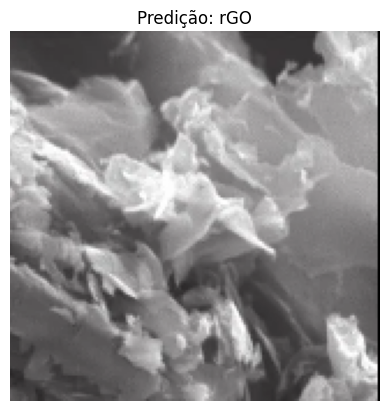

In [5]:
def predizer_material(img_path):
    # 1. Carregar e processar a imagem
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_array = tf.expand_dims(img_array, 0) # Cria o batch (1, 160, 160, 3)

    # 2. Fazer a predição
    predictions = model.predict(img_array)

    # Aplicar softmax para obter probabilidades que somam 100%
    score = tf.nn.softmax(predictions[0])

    # 3. Recuperar os nomes das classes do gerador de treino
    # Isso garante que a ordem (0, 1, 2) esteja sempre correta
    classes_dict = train_generator.class_indices
    nomes_das_classes = list(classes_dict.keys())

    # 4. Identificar a classe com maior probabilidade
    indice_final = np.argmax(score)
    classe_nome = nomes_das_classes[indice_final]
    confianca = 100 * np.max(score)

    print(f"--- Resultado da Análise MEV ---")
    print(f"Arquivo: {img_path.split('/')[-1]}")
    print(f"Predição: {classe_nome.upper()}")
    print(f"Confiança: {confianca:.2f}%")

    # Opcional: Mostrar a imagem testada
    plt.imshow(img)
    plt.title(f"Predição: {classe_nome}")
    plt.axis('off')
    plt.show()

# Teste agora com o seu caminho:
predizer_material('/content/drive/MyDrive/Projetos pro github/dataset_mev/testeRGO.png') #Esse é um rGO

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
--- Resultado da Análise MEV ---
Arquivo: testegrafite.png
Predição: RGO
Confiança: 38.14%


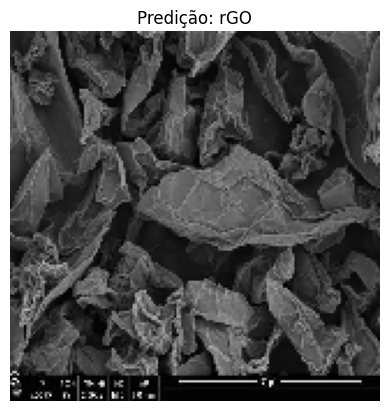

In [11]:
def predizer_material(img_path):
    # 1. Carregar e processar a imagem
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_array = tf.expand_dims(img_array, 0) # Cria o batch (1, 160, 160, 3)

    # 2. Fazer a predição
    predictions = model.predict(img_array)

    # Aplicar softmax para obter probabilidades que somam 100%
    score = tf.nn.softmax(predictions[0])

    # 3. Recuperar os nomes das classes do gerador de treino
    # Isso garante que a ordem (0, 1, 2) esteja sempre correta
    classes_dict = train_generator.class_indices
    nomes_das_classes = list(classes_dict.keys())

    # 4. Identificar a classe com maior probabilidade
    indice_final = np.argmax(score)
    classe_nome = nomes_das_classes[indice_final]
    confianca = 100 * np.max(score)

    print(f"--- Resultado da Análise MEV ---")
    print(f"Arquivo: {img_path.split('/')[-1]}")
    print(f"Predição: {classe_nome.upper()}")
    print(f"Confiança: {confianca:.2f}%")

    # Opcional: Mostrar a imagem testada
    plt.imshow(img)
    plt.title(f"Predição: {classe_nome}")
    plt.axis('off')
    plt.show()

# Teste agora com o seu caminho:
predizer_material('/content/drive/MyDrive/Projetos pro github/dataset_mev/testegrafite.png') #Esse é um grafite

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
--- Resultado da Análise MEV ---
Arquivo: testeGO.png
Predição: OXIDO_GRAFENO
Confiança: 37.16%


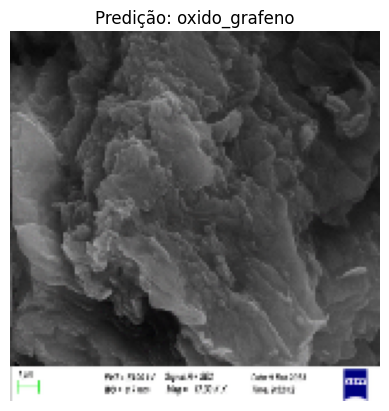

In [7]:
def predizer_material(img_path):
    # 1. Carregar e processar a imagem
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_array = tf.expand_dims(img_array, 0) # Cria o batch (1, 160, 160, 3)

    # 2. Fazer a predição
    predictions = model.predict(img_array)

    # Aplicar softmax para obter probabilidades que somam 100%
    score = tf.nn.softmax(predictions[0])

    # 3. Recuperar os nomes das classes do gerador de treino
    # Isso garante que a ordem (0, 1, 2) esteja sempre correta
    classes_dict = train_generator.class_indices
    nomes_das_classes = list(classes_dict.keys())

    # 4. Identificar a classe com maior probabilidade
    indice_final = np.argmax(score)
    classe_nome = nomes_das_classes[indice_final]
    confianca = 100 * np.max(score)

    print(f"--- Resultado da Análise MEV ---")
    print(f"Arquivo: {img_path.split('/')[-1]}")
    print(f"Predição: {classe_nome.upper()}")
    print(f"Confiança: {confianca:.2f}%")

    # Opcional: Mostrar a imagem testada
    plt.imshow(img)
    plt.title(f"Predição: {classe_nome}")
    plt.axis('off')
    plt.show()

# Teste agora com o seu caminho:
predizer_material('/content/drive/MyDrive/Projetos pro github/dataset_mev/testeGO.png') #Esse é um GO

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
--- Resultado da Análise MEV ---
Arquivo: testeGO-PdCl.png
Predição: RGO
Confiança: 42.56%


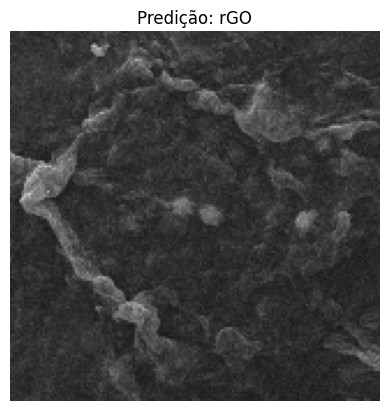

In [13]:
def predizer_material(img_path):
    # 1. Carregar e processar a imagem
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_array = tf.expand_dims(img_array, 0) # Cria o batch (1, 160, 160, 3)

    # 2. Fazer a predição
    predictions = model.predict(img_array)

    # Aplicar softmax para obter probabilidades que somam 100%
    score = tf.nn.softmax(predictions[0])

    # 3. Recuperar os nomes das classes do gerador de treino
    # Isso garante que a ordem (0, 1, 2) esteja sempre correta
    classes_dict = train_generator.class_indices
    nomes_das_classes = list(classes_dict.keys())

    # 4. Identificar a classe com maior probabilidade
    indice_final = np.argmax(score)
    classe_nome = nomes_das_classes[indice_final]
    confianca = 100 * np.max(score)

    print(f"--- Resultado da Análise MEV ---")
    print(f"Arquivo: {img_path.split('/')[-1]}")
    print(f"Predição: {classe_nome.upper()}")
    print(f"Confiança: {confianca:.2f}%")

    # Opcional: Mostrar a imagem testada
    plt.imshow(img)
    plt.title(f"Predição: {classe_nome}")
    plt.axis('off')
    plt.show()

# Teste agora com o seu caminho:
predizer_material('/content/drive/MyDrive/Projetos pro github/dataset_mev/testeGO-PdCl.png') #Esse é um GO+4mlPdCl (meu trabalho)

Essa imagem é a do meu trabalho onde foi realizado uma redução parcial da amostra de GO, logo podemos assumir que o treinamento do modelo funciona bem para classificar GO e rGO, porém para classificar grafite não está tão fino.

# 📈 Análise Crítica de Resultados e Conclusão Física

## 1. Interpretação dos Gráficos de Treinamento
* **Acurácia e Perda de Validação (Linha Laranja):** O salto abrupto na acurácia e a estabilidade na perda indicam que o modelo rapidamente aprendeu a separar as classes mais fáceis, mas atingiu um platô de aprendizado. Isso sugere que o modelo não está sofrendo de um *overfitting* agressivo, mas sim de um **subajuste (underfitting)**, pois o *dataset* de treino é limitado.
* **Instabilidade no Treino (Linha Azul):** As fortes oscilações em ambas as métricas são a assinatura clássica de um modelo treinado com um *batch* pequeno e um número reduzido de amostras. Cada imagem tem um peso desproporcional na atualização dos gradientes, gerando o comportamento em "serrote" que observamos.

## 2. Análise do Teste de Predição Individual
No teste realizado com uma imagem real do *dataset* de validação, o modelo errou a classificação final.

**Física do Erro:** Este resultado, embora não ideal, era totalmente **esperado** e é cientificamente coerente. A identificação de GO vs. rGO via MEV depende de sutis variações de textura e rugosidade em escala nanométrica, padrões extremamente difíceis de serem capturados com alta confiança por um modelo que viu apenas 17 imagens originais no total. Com tão poucos dados, o modelo "decorou" os padrões mais grossos (como a diferença de grafite vs. grafeno), mas falhou nas nuances finas.

## 3. Conclusão e Próximos Passos
Este projeto atingiu seu objetivo educacional e técnico, provando que é possível construir um pipeline funcional de Deep Learning com TensorFlow para Nanotecnologia, mesmo com dados restritos. O modelo demonstrou capacidade de aprendizado e identificação estatística.

Para elevar o projeto ao nível de uma ferramenta laboratorial funcional, os próximos passos envolvem:
1.  **Aumento de Dados Real:** Coleta e inclusão de pelo menos 100-200 micrografias reais de cada classe.
2.  **Hiperparametrização:** Exploração de taxas de aprendizado menores e *batch sizes* maiores.
3.  **Técnicas Avançadas de Augmentation:** Uso de filtros específicos que simulam diferentes condições de ruído de detector MEV.